# Predicting Major Injuries in NBA Players
**DTSC 2301 · Personal Portfolio Project Two** · Timothy Pearson

**Research question:** What factors can we use to predict whether an NBA player will suffer a *major* injury next season?

| | |
|---|---|
| **Task** | Binary classification of `major_next` (major injury next season), ~11% positive |
| **Unit** | One player-season, 2015-16 to 2023-24 (outcomes 2016-17 to 2024-25) |
| **Data** | Pro Sports Transactions injury log + Basketball-Reference stats and bios |
| **Models** | Logistic Regression, Random Forest, Gradient Boosting vs. two baselines |
| **Validation** | Train on 2016-2021 seasons, test on 2022-2024; forward-chaining CV for tuning |

## 1. Problem and Background
A **major injury** is a structural one: a tear/rupture, fracture, dislocation or surgery. Sprains, soreness, illness and rest do not count. A reliable risk ranking would help medical staff prioritize prevention and help front offices price contract risk; major injuries can permanently reduce performance (Amin et al., 2013).

Research points to three kinds of predictors:
- **Workload:** injury risk rises with minutes and fatigue (Lewis, 2018) and schedule density (Teramoto et al., 2017); sudden workload spikes matter most (Gabbett, 2016).
- **Injury history:** previous injury is one of the strongest risk factors (Hägglund et al., 2006).
- **Body and position:** knee and foot injuries cost NBA players the most games (Drakos et al., 2010).

Machine learning can forecast injuries with rich tracking data (Rossi et al., 2018), but only season-level stats are public, so **modest** performance is expected.

In [1]:
import re, time, unicodedata, warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_DIR = Path('nba_injury_data')
DATA_DIR.mkdir(exist_ok=True)
BLUE, ORANGE, GRAY, INK2 = '#2a78d6', '#eb6834', '#8a8984', '#52514e'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e4e3df', 'axes.axisbelow': True, 'axes.titleweight': 'bold',
                     'axes.titlelocation': 'left', 'legend.frameon': False, 'figure.dpi': 110})

## 2. Data
| Source | Contents |
|---|---|
| Pro Sports Transactions injury log, 2015-2025 (scraped by Wright, 2025) | ~28,000 transactions: date, player ruled out, free-text note |
| Basketball-Reference season tables (Sports Reference, n.d.-a) | ~5,400 player-seasons: age, position, games, minutes, usage, rebounding, fouls |
| Basketball-Reference player index (Sports Reference, n.d.-b) | Height, weight, first season |

The injury log only covers *publicly reported* injuries and starts in October 2015. Data is downloaded once and cached in `nba_injury_data/`.

In [2]:
INJURY_URL = 'https://raw.githubusercontent.com/xcrunner011/NBA_Injury_Scraper-2015-2025-/main/injuries_2015-2025.csv'
BREF = 'https://www.basketball-reference.com'
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/126.0'}

def fetch_table(url):
    r = requests.get(url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    time.sleep(3.5)  # Basketball-Reference rate limit
    return pd.read_html(StringIO(r.content.decode('utf-8')))[0]

def clean_season(adv, pg, season):
    # One row per player; traded players keep their season-total row (listed first)
    keep = lambda t: t[t['Rk'].notna() & (t['Player'] != 'League Average')].drop_duplicates('Player')
    out = keep(adv).drop(columns=['Rk', 'Awards'], errors='ignore').merge(
        keep(pg)[['Player', 'FGA', 'FTA', 'PF', 'PTS', 'TRB', 'AST']], on='Player', how='left')
    return out.assign(season=season)

def build_bios():
    pages = []
    for letter in 'abcdefghijklmnopqrstuvwxyz':
        try:
            pages.append(fetch_table(f'{BREF}/players/{letter}/'))
        except ValueError:  # index page with no table
            pass
    bios = pd.concat(pages)
    return bios[pd.to_numeric(bios['To'], errors='coerce') >= 2016]

def cached(name, build):
    path = DATA_DIR / name
    if not path.exists():
        build().to_csv(path, index=False)
    return pd.read_csv(path)

injuries_raw = cached('injuries_2015_2025_raw.csv', lambda: pd.read_csv(INJURY_URL))
stats_raw = cached('bref_player_seasons_2016_2025.csv', lambda: pd.concat(
    [clean_season(fetch_table(f'{BREF}/leagues/NBA_{y}_advanced.html'),
                  fetch_table(f'{BREF}/leagues/NBA_{y}_per_game.html'), y) for y in range(2016, 2026)]))
bios_raw = cached('bref_player_bios.csv', build_bios)
print(f'Injury log {injuries_raw.shape} | stats {stats_raw.shape} | bios {bios_raw.shape}')

Injury log (28144, 7) | stats (5386, 34) | bios (1554, 8)


## 3. Data Preparation and Features
1. **Name matching:** names are normalized (accents, punctuation, "Jr.") plus a short nickname list, so *Luka Dončić* matches *Luka Doncic*.
2. **Labelling notes:** rest, illness, COVID protocols and suspensions are not injuries. A note is **major** if it mentions a tear, rupture, fracture, broken bone, dislocation, surgery or ACL, *unless* it says "recovering from" (an old injury) or is facial/dental.
3. **Seasons** run October to September, so off-season surgery stays with the season it followed (avoids leakage). Reports within 7 days are merged into one **injury episode**.
4. **Target:** `major_next` looks one season ahead. Player-seasons are kept only if the player was still in the league next season, and only with **10+ games** (low-minute rows are noisy).

All features are known at the end of season *t*: age, height, weight, workload (`MP`, `mpg`, `g_share`, `gs_share`, `mp_change`), style (`USG%`, `TRB%`, `FTr`, `3PAr`, fouls per game), injury history (`inj_episodes`, `inj_prev`, `major`, `prior_major`) and position. Unknown values (e.g., last season for 2015-16 veterans) are left missing and median-imputed **inside** the pipeline.

In [3]:
def norm_name(name):
    s = unicodedata.normalize('NFKD', str(name)).encode('ascii', 'ignore').decode().lower().replace('*', '')
    s = re.sub(r"[.'`]", '', s).replace('-', ' ')
    return re.sub(r'\s+', ' ', re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', s)).strip()

ALIASES = {'alex ajinca': 'alexis ajinca', 'enes kanter': 'enes freedom', 'herb jones': 'herbert jones',
           'moe harkless': 'maurice harkless', 'moe wagner': 'moritz wagner', 'wes matthews': 'wesley matthews',
           'juan hernangomez': 'juancho hernangomez', 'iggy brazdeikis': 'ignas brazdeikis',
           'naz long': 'naz mitrou long', 'maybyner hilario': 'nene', 'jake wiley': 'jacob wiley',
           'bj boston': 'brandon boston'}
stats = stats_raw.assign(key=stats_raw['Player'].map(norm_name))
bios = bios_raw.assign(key=bios_raw['Player'].map(norm_name))

# Label injury transactions
inj = injuries_raw[injuries_raw['Relinquished'].notna()].copy()
inj['Date'] = pd.to_datetime(inj['Date'])
inj['key'] = inj['Relinquished'].str.replace(r'^[^\w]+', '', regex=True).map(norm_name).replace(ALIASES)
inj['season'] = np.where(inj['Date'].dt.month >= 10, inj['Date'].dt.year + 1, inj['Date'].dt.year)
inj.loc[inj['Date'].between('2020-10-01', '2020-10-31'), 'season'] = 2020  # 2020 bubble
inj = inj[inj['season'].between(2016, 2025)]
notes = inj['Notes'].fillna('').str.lower().str.strip()
NON_INJURY = (r'\brest\b|illness|personal|protocol|covid|suspen|\bflu\b|conditioning|management|g league|'
              r'not injury|virus|family|birth|bereavement|sick|\bill\b|gastro|food poison|\bcold\b|migraine')
MAJOR = r'\btorn\b|\btears?\b|ruptur|fractur|\bbroken\b|dislocat|surger|surgical|\bacl\b'
NOT_MAJOR = r'recover|nose|nasal|append|tonsil|dental|tooth|teeth|\beye\b|orbital|facial|jaw'
inj['is_injury'] = ~notes.str.contains(NON_INJURY) & ~notes.isin(['', 'placed on il'])
inj['is_major'] = inj['is_injury'] & notes.str.contains(MAJOR) & ~notes.str.contains(NOT_MAJOR)

# Injury episodes (reports within 7 days = one episode) and major flag per player-season
inj_only = inj[inj['is_injury']].sort_values(['key', 'Date'])
gap = inj_only.groupby('key')['Date'].diff().dt.days
episodes = inj_only[gap.isna() | (gap > 7)]
inj_season = (episodes.groupby(['key', 'season']).size().rename('inj_episodes').to_frame()
              .join(inj[inj['is_major']].groupby(['key', 'season']).size().rename('major')).fillna(0).reset_index())
inj_season['major'] = (inj_season['major'] > 0).astype(int)

# Merge bios, injuries and next-season outcome
ht = bios['Ht'].str.split('-', expand=True).astype(float)
bios['height_in'], bios['weight_lb'] = ht[0] * 12 + ht[1], pd.to_numeric(bios['Wt'], errors='coerce')
bios['first_season'] = pd.to_numeric(bios['From'], errors='coerce')
df = (stats.merge(bios[['key', 'height_in', 'weight_lb', 'first_season']], on='key', how='left')
           .merge(inj_season, on=['key', 'season'], how='left'))
df[['inj_episodes', 'major']] = df[['inj_episodes', 'major']].fillna(0)
in_league = pd.concat([stats[['key', 'season']], inj_season[['key', 'season']]]).drop_duplicates()
df = df.merge(in_league.assign(season=in_league['season'] - 1, in_league_next=1), on=['key', 'season'], how='left')
target = inj_season[['key', 'season', 'major']].rename(columns={'major': 'major_next'}).assign(
    season=lambda d: d['season'] - 1)
df = df.merge(target, on=['key', 'season'], how='left')
df = df[(df['season'] <= 2024) & (df['in_league_next'] == 1)].copy()
df['major_next'] = df['major_next'].fillna(0).astype(int)

# Feature engineering
df = df.sort_values(['key', 'season']).reset_index(drop=True)
df['experience'] = df['season'] - df['first_season']
df['mpg'] = df['MP'] / df['G']
df['g_share'] = df['G'] / df.groupby('season')['G'].transform('max')  # adjusts for shortened 2020, 2021
df['gs_share'] = df['GS'] / df['G']
df['pf_pg'] = df['PF']
df['pos'] = df['Pos'].str.split('-').str[0].map({'PG': 'G', 'SG': 'G', 'SF': 'F', 'PF': 'F', 'C': 'C'})
prev_mp = stats[['key', 'season', 'MP']].assign(season=lambda d: d['season'] + 1).rename(columns={'MP': 'MP_prev'})
prev_inj = inj_season[['key', 'season', 'inj_episodes']].assign(season=lambda d: d['season'] + 1).rename(
    columns={'inj_episodes': 'inj_prev'})
df = df.merge(prev_mp, on=['key', 'season'], how='left').merge(prev_inj, on=['key', 'season'], how='left')
rookie = df['experience'] <= 0
df.loc[rookie, 'MP_prev'] = 0
df['inj_prev'] = df['inj_prev'].fillna(0)
df.loc[(df['season'] == 2016) & ~rookie, 'inj_prev'] = np.nan  # before the injury log starts
df['mp_change'] = df['MP'] - df['MP_prev']
df['prior_major'] = df.groupby('key')['major'].cumsum() - df['major']  # earlier seasons only

model_df = df[df['G'] >= 10].reset_index(drop=True)
print(f'Major injuries labelled: {inj.is_major.sum():,} | modeling rows: {len(model_df):,} '
      f'| positive rate: {model_df["major_next"].mean():.1%}')

Major injuries labelled: 827 | modeling rows: 3,640 | positive rate: 11.7%


## 4. Exploration

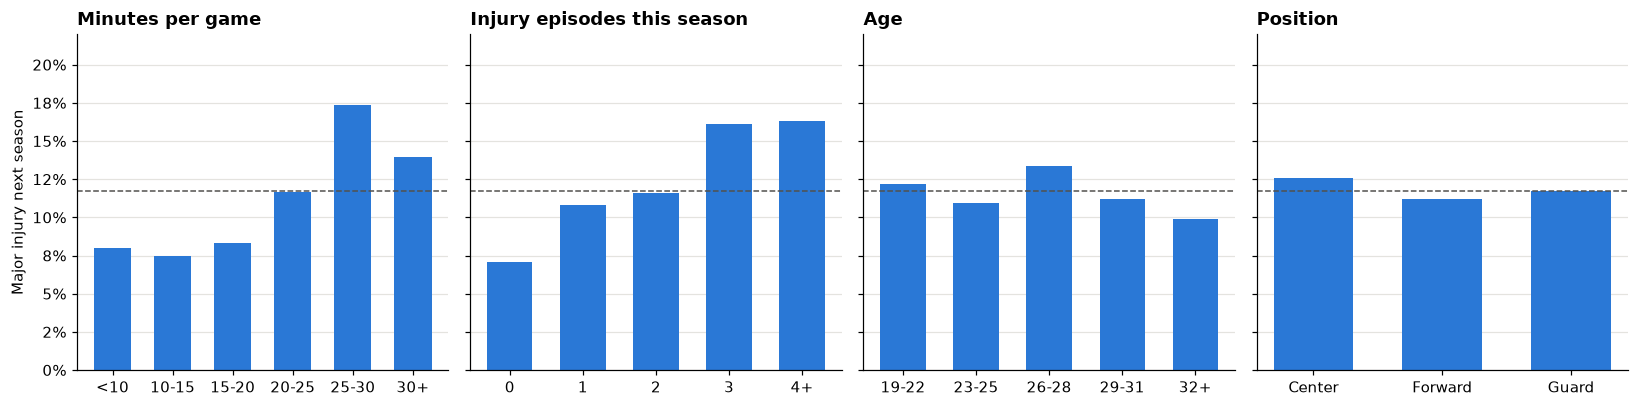

Correlation with major_next:
inj_episodes    0.099
mpg             0.094
MP              0.079
gs_share        0.078
inj_prev        0.077
pf_pg           0.070
major           0.053
USG%            0.048
FTr             0.032
TRB%            0.015
height_in       0.015
prior_major     0.014
weight_lb       0.006
mp_change       0.003
Age            -0.011
3PAr           -0.034


In [4]:
overall = model_df['major_next'].mean()
panels = [
    ('Minutes per game', pd.cut(model_df['mpg'], [0, 10, 15, 20, 25, 30, 45],
                                labels=['<10', '10-15', '15-20', '20-25', '25-30', '30+'])),
    ('Injury episodes this season', pd.cut(model_df['inj_episodes'], [-1, 0, 1, 2, 3, 20],
                                           labels=['0', '1', '2', '3', '4+'])),
    ('Age', pd.cut(model_df['Age'], [18, 22, 25, 28, 31, 45], labels=['19-22', '23-25', '26-28', '29-31', '32+'])),
    ('Position', model_df['pos'].map({'G': 'Guard', 'F': 'Forward', 'C': 'Center'})),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (title, bins) in zip(axes, panels):
    g = model_df.groupby(bins, observed=True)['major_next'].mean()
    ax.bar(g.index.astype(str), g.values, color=BLUE, width=0.62)
    ax.axhline(overall, color=INK2, ls='--', lw=1)
    ax.set(title=title, ylim=(0, 0.22))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Major injury next season')
plt.tight_layout()
plt.show()

corr_cols = ['Age', 'height_in', 'weight_lb', 'MP', 'mpg', 'gs_share', 'mp_change', 'USG%', 'TRB%', 'FTr',
             '3PAr', 'pf_pg', 'inj_episodes', 'inj_prev', 'major', 'prior_major']
print('Correlation with major_next:')
print(model_df[corr_cols].corrwith(model_df['major_next']).sort_values(ascending=False).round(3).to_string())

**Findings** (dashed line = overall rate, ~12%):
- **Class imbalance:** only ~12% of player-seasons are followed by a major injury, so accuracy is misleading; I use **ROC-AUC** and **PR-AUC**.
- **Workload and injury history** show the clearest patterns: players at 25+ minutes per game, or with 3+ injury episodes, have roughly double the rate of low-minute, injury-free players.
- **Age and position** show almost no pattern (possibly survivor bias: older players still in the league are the durable ones).
- Every correlation with the target is weak (|r| ≤ 0.10), so a modest model is the realistic goal. `experience` was dropped because it duplicates `Age` (r = 0.90).

## 5. Modeling
- **Time-based split:** train on feature seasons 2015-16 to 2020-21, test on 2021-22 to 2023-24 (outcomes 2022-23 to 2024-25). The test set is used once.
- **Tuning:** `GridSearchCV` on three forward-chaining folds (train ≤ 2018 → validate 2019, and so on), optimizing log loss. Imputation, scaling and one-hot encoding are inside the pipeline, so nothing leaks from validation data.
- **Baselines:** (1) always predict "no injury"; (2) an **"injury-prone" rule** that ranks players by major injury this season, then by injury episodes.
- **Selection rule (set before testing):** the simplest model within one standard deviation of the best CV ROC-AUC.

In [5]:
NUM_FEATURES = ['Age', 'height_in', 'weight_lb', 'MP', 'mpg', 'g_share', 'gs_share', 'mp_change',
                'USG%', 'TRB%', 'FTr', '3PAr', 'pf_pg', 'inj_episodes', 'inj_prev', 'major', 'prior_major']
FEATURES = NUM_FEATURES + ['pos']
train = model_df[model_df['season'] <= 2021].reset_index(drop=True)
test = model_df[model_df['season'] >= 2022].reset_index(drop=True)
X_train, y_train, X_test, y_test = train[FEATURES], train['major_next'], test[FEATURES], test['major_next']
cv_folds = [(np.where(train['season'] < v)[0], np.where(train['season'] == v)[0]) for v in (2019, 2020, 2021)]

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['pos'])])
models = {
    'Logistic Regression': (LogisticRegression(max_iter=5000),
                            {'clf__C': [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 1.0]}),
    'Random Forest': (RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
                      {'clf__min_samples_leaf': [10, 25, 50, 100, 200], 'clf__max_depth': [None, 6],
                       'clf__max_features': ['sqrt', 0.5]}),
    'Gradient Boosting': (HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                          {'clf__learning_rate': [0.01, 0.03, 0.1], 'clf__max_depth': [2, 3],
                           'clf__max_iter': [100, 300], 'clf__min_samples_leaf': [50, 100, 200]}),
}
searches, cv_rows = {}, []
for name, (clf, grid) in models.items():
    s = GridSearchCV(Pipeline([('prep', preprocess), ('clf', clf)]), grid, cv=cv_folds, n_jobs=-1,
                     scoring={'log_loss': 'neg_log_loss', 'roc_auc': 'roc_auc'}, refit='log_loss').fit(X_train, y_train)
    searches[name] = s
    cv_rows.append({'model': name, 'CV ROC-AUC': s.cv_results_['mean_test_roc_auc'][s.best_index_],
                    'CV SD': s.cv_results_['std_test_roc_auc'][s.best_index_],
                    'best settings': {k.replace('clf__', ''): v for k, v in s.best_params_.items()}})
rule_score = lambda d: d['major'] * 10 + d['inj_episodes']
rule_cv = [roc_auc_score(y_train.iloc[va], rule_score(X_train.iloc[va])) for _, va in cv_folds]
cv_rows.append({'model': 'Baseline: injury-prone rule', 'CV ROC-AUC': np.mean(rule_cv), 'CV SD': np.std(rule_cv),
                'best settings': '-'})
cv_table = pd.DataFrame(cv_rows).set_index('model').sort_values('CV ROC-AUC', ascending=False)

best = cv_table.drop('Baseline: injury-prone rule').iloc[0]
FINAL_NAME = next(m for m in models if cv_table.loc[m, 'CV ROC-AUC'] >= best['CV ROC-AUC'] - best['CV SD'])
final_model = searches[FINAL_NAME].best_estimator_
print('Selected final model:', FINAL_NAME)
cv_table.round(3)

Selected final model: Logistic Regression


,CV ROC-AUC,CV SD,best settings
model,,,
Random Forest,0.588,0.013,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
Gradient Boosting,0.586,0.009,"{'learning_rate': 0.01, 'max_depth': 2, 'max_i..."
Logistic Regression,0.581,0.019,{'C': 0.003}
Baseline: injury-prone rule,0.562,0.002,-


## 6. Evaluation on the Held-Out Test Seasons

In [6]:
def evaluate(scores, y=y_test, top=0.20):
    # Precision/recall if the top 20% highest-risk players form a "watch list" (ties broken at random)
    order = np.lexsort((np.random.default_rng(RANDOM_STATE).random(len(y)), -np.asarray(scores)))
    flag = np.zeros(len(y), bool)
    if np.ptp(scores) > 0:
        flag[order[:int(round(top * len(y)))]] = True
    prec = y[flag].mean() if flag.any() else 0.0
    return {'ROC-AUC': roc_auc_score(y, scores), 'PR-AUC': average_precision_score(y, scores),
            'Brier': brier_score_loss(y, scores) if scores.max() <= 1 else np.nan,
            'Precision@20%': prec, 'Recall@20%': y[flag].sum() / y.sum(),
            'Accuracy': ((scores >= 0.5) == y).mean() if scores.max() <= 1 else np.nan}

test_scores = {n: s.best_estimator_.predict_proba(X_test)[:, 1] for n, s in searches.items()}
test_scores['Baseline: injury-prone rule'] = rule_score(X_test).values.astype(float)
results = pd.DataFrame({'Baseline: always "no injury"': evaluate(np.full(len(y_test), y_train.mean())),
                        **{n: evaluate(s) for n, s in test_scores.items()}}).T

# Bootstrap 95% CI for ROC-AUC
rng, yv, boot = np.random.default_rng(RANDOM_STATE), y_test.values, {n: [] for n in test_scores}
for _ in range(1000):
    idx = rng.integers(0, len(yv), len(yv))
    for n, s in test_scores.items():
        boot[n].append(roc_auc_score(yv[idx], s[idx]))
results['AUC 95% CI'] = pd.Series({n: f'{np.percentile(v, 2.5):.3f}-{np.percentile(v, 97.5):.3f}' for n, v in boot.items()})
results.style.format({'ROC-AUC': '{:.3f}', 'PR-AUC': '{:.3f}', 'Brier': '{:.4f}', 'Precision@20%': '{:.1%}',
                      'Recall@20%': '{:.1%}', 'Accuracy': '{:.1%}'}, na_rep='-')

,ROC-AUC,PR-AUC,Brier,Precision@20%,Recall@20%,Accuracy,AUC 95% CI
"Baseline: always ""no injury""",0.500,0.108,0.0965,0.0%,0.0%,89.2%,-
Logistic Regression,0.593,0.135,0.0959,14.4%,26.7%,89.2%,0.544-0.640
Random Forest,0.580,0.138,0.0960,12.4%,23.0%,89.2%,0.534-0.625
Gradient Boosting,0.575,0.133,0.0960,12.4%,23.0%,89.2%,0.529-0.620
Baseline: injury-prone rule,0.584,0.147,-,16.0%,29.6%,-,0.528-0.636


**Results**
- **Accuracy is useless:** every model scores ~89%, the same as always predicting "no injury."
- **All models beat chance:** the final logistic regression reaches test ROC-AUC **≈ 0.59**, matching cross-validation, so it generalized to new seasons. The three models are nearly tied, and tuning chose heavily regularized settings for all of them, a sign the signal is weak.
- **But the gain over the injury-prone rule is small** and within the confidence intervals; the rule even has slightly higher watch-list precision.
- **Final model: Logistic Regression**, chosen by the pre-declared rule. Its main advantage over the rule is a calibrated probability for *every* player, interpretable coefficients and less risk of overfitting.

## 7. Interpretation

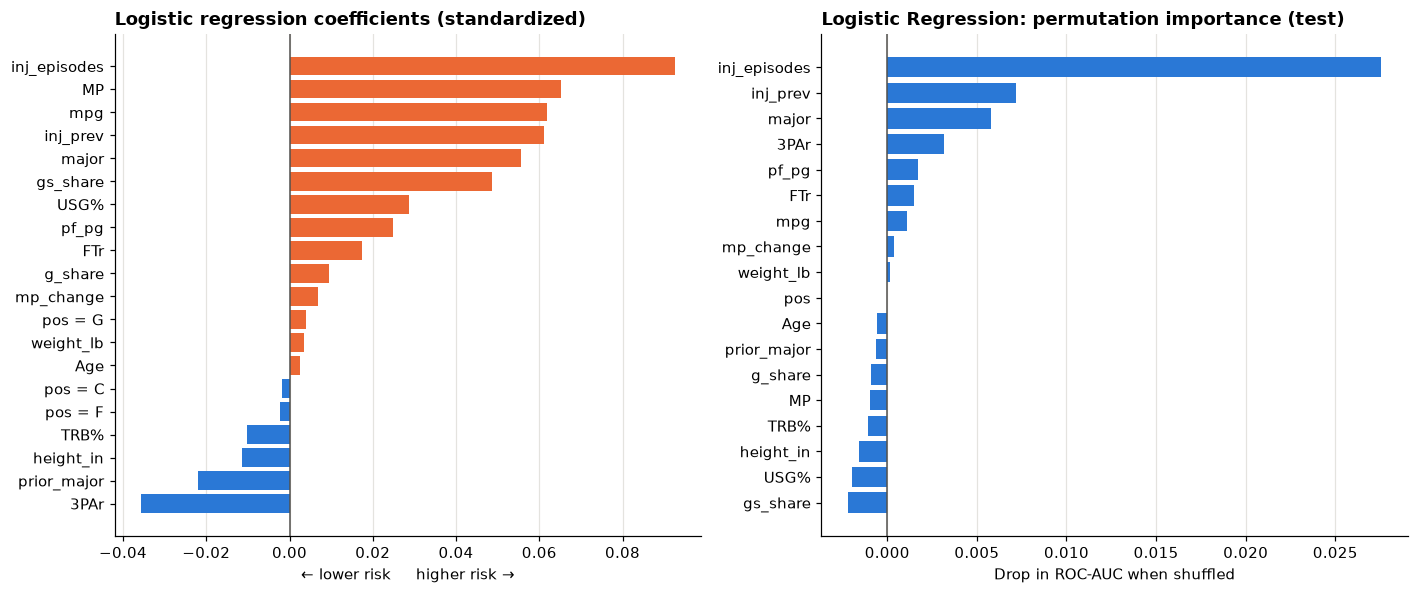

Actual major-injury rate by predicted-risk group (test):
risk
Lowest 20%      6.8%
2nd             7.6%
Middle         10.4%
4th            14.8%
Highest 20%    14.4%


In [7]:
lr = searches['Logistic Regression'].best_estimator_
cats = lr.named_steps['prep'].named_transformers_['cat'].categories_[0]
coefs = pd.Series(lr.named_steps['clf'].coef_[0], index=NUM_FEATURES + [f'pos = {c}' for c in cats]).sort_values()
perm = permutation_importance(final_model, X_test, y_test, scoring='roc_auc', n_repeats=30,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].barh(coefs.index, coefs.values, color=[ORANGE if v > 0 else BLUE for v in coefs.values])
axes[0].set(title='Logistic regression coefficients (standardized)', xlabel='← lower risk     higher risk →')
axes[1].barh(imp.index, imp.values, color=BLUE)
axes[1].set(title=f'{FINAL_NAME}: permutation importance (test)', xlabel='Drop in ROC-AUC when shuffled')
for ax in axes:
    ax.axvline(0, color=INK2, lw=1)
    ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

test['risk'] = final_model.predict_proba(X_test)[:, 1]
groups = pd.qcut(test['risk'].rank(method='first'), 5, labels=['Lowest 20%', '2nd', 'Middle', '4th', 'Highest 20%'])
print('Actual major-injury rate by predicted-risk group (test):')
print(test.groupby(groups, observed=True)['major_next'].mean().map('{:.1%}'.format).to_string())

- **Recent injury history is the strongest predictor.** `inj_episodes` has the largest coefficient and permutation importance, followed by `inj_prev` and `major`, consistent with Hägglund et al. (2006).
- **Workload raises risk.** Minutes, minutes per game and starts all have positive coefficients (Lewis, 2018). Their individual permutation importance is small because they are highly correlated with each other.
- **Style matters a little:** usage, fouls and free-throw rate raise risk; a high 3-point rate lowers it (less contact).
- **Age, weight, position and minute spikes add almost nothing.** Season totals are too coarse to capture the short-term spikes Gabbett (2016) describes.
- The highest-risk group is injured at **about twice the rate** of the lowest, but even it stays healthy ~85% of the time. These are **associations, not causes**: minutes partly measure exposure.

## 8. Limitations and Ethics
- **Noisy label:** the target depends on what teams publicly report and on keyword rules; "surgery" can mean an ACL reconstruction or a minor clean-up.
- **Short history and survivor bias:** injuries before 2015 are invisible, and players whose careers ended drop out of the data.
- **Missing variables:** daily load, tracking and medical data are private.
- **Harm from errors:** a false "injury-prone" label could cost a player a contract or reputation. With ROC-AUC ≈ 0.6 the model should only help *prioritize attention* (e.g., who to screen first), never decide contracts, playing time or medical clearance.
- **Next steps:** game-level workload (back-to-backs, recent minutes), tracking data, injury severity in games missed, and body-part-specific models.

## 9. Conclusion
The best predictors of a major NBA injury next season are **recent injury history**, then **workload**, then a small effect of **playing style**. Age, size, position and minute changes add little. The final model ranks players better than chance (test ROC-AUC ≈ 0.59) but barely beats a simple "injury-prone" rule. From public season-level data, most major injuries look **largely unpredictable**; better forecasts would need the private, high-resolution data teams collect (Rossi et al., 2018).

## 10. References 

**Data**
- Pro Sports Transactions. (n.d.). *Basketball transactions search* [Data set]. https://www.prosportstransactions.com/basketball/Search/Search.php
- Wright, W. (2025). *NBA injury data from 2015-2025* [Data set]. GitHub. https://github.com/xcrunner011/NBA_Injury_Scraper-2015-2025-
- Sports Reference. (n.d.-a). *NBA season advanced and per-game statistics* [Data set]. https://www.basketball-reference.com/leagues/
- Sports Reference. (n.d.-b). *NBA & ABA player directory* [Data set]. https://www.basketball-reference.com/players/

**References (APA 7)**
- Amin, N. H., Old, A. B., Tabb, L. P., Garg, R., Toossi, N., & Cerynik, D. L. (2013). Performance outcomes after repair of complete Achilles tendon ruptures in National Basketball Association players. *The American Journal of Sports Medicine, 41*(8), 1864–1868. https://doi.org/10.1177/0363546513490659
- Drakos, M. C., Domb, B., Starkey, C., Callahan, L., & Allen, A. A. (2010). Injury in the National Basketball Association: A 17-year overview. *Sports Health, 2*(4), 284–290. https://doi.org/10.1177/1941738109357303
- Gabbett, T. J. (2016). The training–injury prevention paradox: Should athletes be training smarter *and* harder? *British Journal of Sports Medicine, 50*(5), 273–280. https://doi.org/10.1136/bjsports-2015-095788
- Hägglund, M., Waldén, M., & Ekstrand, J. (2006). Previous injury as a risk factor for injury in elite football: A prospective study over two consecutive seasons. *British Journal of Sports Medicine, 40*(9), 767–772. https://doi.org/10.1136/bjsm.2006.026609
- Lewis, M. (2018). It's a hard-knock life: Game load, fatigue, and injury risk in the National Basketball Association. *Journal of Athletic Training, 53*(5), 503–509. https://doi.org/10.4085/1062-6050-243-17
- Teramoto, M., Cross, C. L., Cushman, D. M., Maak, T. G., Petron, D. J., & Willick, S. E. (2017). Game injuries in relation to game schedules in the National Basketball Association. *Journal of Science and Medicine in Sport, 20*(3), 230–235. https://doi.org/10.1016/j.jsams.2016.08.020

